<a href="https://colab.research.google.com/github/Abdulkhabeer70/Face_Mask_Detection/blob/main/04_Ensemble_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4: Ensemble Methods & Comprehensive Evaluation

**Face Mask Detection — Deep Learning Academic Project**

---

## Overview

In this notebook, we combine the three models trained in previous notebooks — a **Custom CNN**, **MobileNetV2**, and **ResNet50** — into an **ensemble** that leverages each model's individual strengths. We then perform a rigorous, side-by-side evaluation of all four classifiers (three individual models plus the ensemble) using a comprehensive suite of metrics and visualisations.

### Objectives

1. Load all three trained models and the preprocessed test data from Google Drive.
2. Construct a **Weighted Average Ensemble** whose weights are optimised via `scipy.optimize.minimize`.
3. Evaluate every model on the held-out test set using accuracy, precision, recall, and F1-score.
4. Produce confusion matrices, ROC curves, Precision-Recall curves, and comparative bar charts.
5. Identify the single best-performing configuration and prepare it for deployment.

---

## 1. Setup & Data Loading

We begin by mounting Google Drive, installing any required packages, and loading the preprocessed `.npy` arrays along with the three Keras models.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from scipy.optimize import minimize

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ── Paths (adjust to your Google Drive layout) ──────────────────────────────
DRIVE_BASE = '/content/drive/MyDrive/Face_Mask_Detection'
DATA_DIR   = os.path.join(DRIVE_BASE, 'data')
MODEL_DIR  = os.path.join(DRIVE_BASE, 'models')

# ── Load preprocessed data ───────────────────────────────────────────────────
X_val  = np.load(os.path.join(DATA_DIR, 'X_val.npy'))
y_val  = np.load(os.path.join(DATA_DIR, 'y_val.npy'))
X_test = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

print(f"Validation set : X_val  {X_val.shape}, y_val  {y_val.shape}")
print(f"Test set       : X_test {X_test.shape}, y_test {y_test.shape}")
print(f"Class distribution (test): {np.unique(y_test, return_counts=True)}")

Validation set : X_val  (1133, 224, 224, 3), y_val  (1133,)
Test set       : X_test (1133, 224, 224, 3), y_test (1133,)
Class distribution (test): (array([0., 1.], dtype=float32), array([574, 559]))


In [5]:
# ── Load the three trained models ─────────────────────────────────────────────
model_custom = keras.models.load_model(os.path.join(MODEL_DIR, 'custom_cnn.keras'))
model_mobile = keras.models.load_model(os.path.join(MODEL_DIR, 'mobilenetv2.keras'))
model_resnet = keras.models.load_model(os.path.join(MODEL_DIR, 'resnet50.keras'))

models = {
    'Custom CNN'  : model_custom,
    'MobileNetV2' : model_mobile,
    'ResNet50'    : model_resnet,
}

for name, m in models.items():
    print(f"{name:15s} — parameters: {m.count_params():,}")

Custom CNN      — parameters: 490,689
MobileNetV2     — parameters: 2,586,177
ResNet50        — parameters: 24,768,385


---

## 2. Ensemble Methods — Background

Ensemble learning combines multiple models to produce predictions that are generally more accurate and robust than any single constituent model. The main families of ensemble techniques are:

| Technique | Core Idea | Examples |
|-----------|-----------|----------|
| **Bagging** | Train independent models on bootstrapped subsets of the data and aggregate their predictions (e.g., majority vote). | Random Forest |
| **Boosting** | Train models sequentially; each new model focuses on the errors of the previous ensemble. | AdaBoost, XGBoost, LightGBM |
| **Stacking** | Train a *meta-learner* on the outputs of base models to learn the optimal combination. | Stacked Generalization |
| **Averaging / Weighted Averaging** | Combine the predicted *probabilities* of base models via a (weighted) mean, then threshold. | Model averaging |

### Why Weighted Averaging?

In our case we have three heterogeneous deep learning architectures whose prediction *probabilities* may be calibrated differently. A **weighted average** allows us to assign higher influence to models that perform better on the validation set while still benefiting from diversity. The weights $w_i \geq 0$ satisfy $\sum_i w_i = 1$.

$$\hat{p}_{\text{ensemble}} = \sum_{i=1}^{3} w_i \, \hat{p}_i$$

We find the optimal $w_i$ by maximising accuracy on the **validation** set (equivalently, minimising negative accuracy) using `scipy.optimize.minimize` with appropriate constraints.

### 2.1 Obtain Validation-Set Predictions from Each Model

In [6]:
# Get predicted probabilities on the validation set from each model
val_preds = {}
for name, model in models.items():
    probs = model.predict(X_val, verbose=0)
    # Handle both (N,1) and (N,2) output shapes
    if probs.shape[-1] == 1:
        probs = probs.ravel()
    else:
        probs = probs[:, 1]  # probability of positive class
    val_preds[name] = probs
    pred_labels = (probs >= 0.5).astype(int)
    acc = accuracy_score(y_val, pred_labels)
    print(f"{name:15s} — Val Accuracy: {acc:.4f}")

# Stack into a matrix (N_samples x 3)
val_pred_matrix = np.column_stack([val_preds[n] for n in models])
print(f"\nValidation prediction matrix shape: {val_pred_matrix.shape}")

Custom CNN      — Val Accuracy: 0.9735
MobileNetV2     — Val Accuracy: 0.9956
ResNet50        — Val Accuracy: 0.8994

Validation prediction matrix shape: (1133, 3)


### 2.2 Optimise Ensemble Weights

We define an objective function that, given a weight vector $\mathbf{w}$, computes the **negative accuracy** of the weighted ensemble on the validation set. We then minimise this using Sequential Least Squares Programming (SLSQP) subject to:

- $\sum w_i = 1$ (equality constraint)
- $w_i \geq 0$ (bounds)

In [7]:
def ensemble_neg_accuracy(weights, pred_matrix, y_true):
    """Objective: negative accuracy (to be minimised)."""
    weighted_probs = pred_matrix @ weights
    preds = (weighted_probs >= 0.5).astype(int)
    return -accuracy_score(y_true, preds)


n_models = val_pred_matrix.shape[1]

# Starting point: equal weights
w0 = np.ones(n_models) / n_models

# Constraints & bounds
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
bounds = [(0.0, 1.0)] * n_models

# Run optimisation (multiple restarts for robustness)
best_result = None
best_fun = 0.0

np.random.seed(42)
for trial in range(20):
    if trial == 0:
        w_init = w0.copy()
    else:
        w_init = np.random.dirichlet(np.ones(n_models))  # random point on simplex

    result = minimize(
        ensemble_neg_accuracy,
        w_init,
        args=(val_pred_matrix, y_val),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'ftol': 1e-12}
    )
    if best_result is None or result.fun < best_fun:
        best_result = result
        best_fun = result.fun

optimal_weights = best_result.x
model_names = list(models.keys())

print("=" * 50)
print("Optimal Ensemble Weights")
print("=" * 50)
for name, w in zip(model_names, optimal_weights):
    print(f"  {name:15s}: {w:.4f}")
print(f"\nOptimised Validation Accuracy: {-best_fun:.4f}")

Optimal Ensemble Weights
  Custom CNN     : 0.2570
  MobileNetV2    : 0.6490
  ResNet50       : 0.0940

Optimised Validation Accuracy: 0.9974


### 2.3 Apply Ensemble to the Test Set

In [8]:
# Get predicted probabilities on the test set
test_preds = {}
for name, model in models.items():
    probs = model.predict(X_test, verbose=0)
    if probs.shape[-1] == 1:
        probs = probs.ravel()
    else:
        probs = probs[:, 1]
    test_preds[name] = probs

test_pred_matrix = np.column_stack([test_preds[n] for n in models])

# Weighted ensemble probabilities
ensemble_probs = test_pred_matrix @ optimal_weights
ensemble_labels = (ensemble_probs >= 0.5).astype(int)

test_preds['Ensemble'] = ensemble_probs

print(f"Ensemble Test Accuracy: {accuracy_score(y_test, ensemble_labels):.4f}")

Ensemble Test Accuracy: 0.9974


### 2.4 Save Ensemble Weights

In [9]:
# Save ensemble weights as JSON
weights_dict = {
    'model_names': model_names,
    'optimal_weights': optimal_weights.tolist(),
    'val_accuracy': float(-best_fun),
    'test_accuracy': float(accuracy_score(y_test, ensemble_labels)),
}

weights_path = os.path.join(MODEL_DIR, 'ensemble_weights.json')
with open(weights_path, 'w') as f:
    json.dump(weights_dict, f, indent=2)

print(f"Ensemble weights saved to: {weights_path}")
print(json.dumps(weights_dict, indent=2))

Ensemble weights saved to: /content/drive/MyDrive/Face_Mask_Detection/models/ensemble_weights.json
{
  "model_names": [
    "Custom CNN",
    "MobileNetV2",
    "ResNet50"
  ],
  "optimal_weights": [
    0.2569771277126353,
    0.6490258916101708,
    0.0939969806771939
  ],
  "val_accuracy": 0.9973521624007061,
  "test_accuracy": 0.9973521624007061
}


---

## 3. Comprehensive Evaluation

We now evaluate all four classifiers — Custom CNN, MobileNetV2, ResNet50, and the Weighted Ensemble — on the **test set** using a battery of standard classification metrics and visualisations.

### 3.1 Metrics Computation

In [10]:
CLASS_NAMES = ['No Mask', 'Mask']

all_model_names = list(models.keys()) + ['Ensemble']

# Compute metrics for every model
results = []

for name in all_model_names:
    probs = test_preds[name]
    preds = (probs >= 0.5).astype(int)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds, zero_division=0)
    f1   = f1_score(y_test, preds, zero_division=0)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
    })

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, preds, target_names=CLASS_NAMES))

# Build a comparison DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

# Highlight best per column
print("\n" + "="*60)
print("  COMPARISON TABLE")
print("="*60)
display(results_df.style.highlight_max(axis=0, color='lightgreen').format('{:.4f}'))


  Custom CNN
              precision    recall  f1-score   support

     No Mask       0.98      0.96      0.97       574
        Mask       0.96      0.98      0.97       559

    accuracy                           0.97      1133
   macro avg       0.97      0.97      0.97      1133
weighted avg       0.97      0.97      0.97      1133


  MobileNetV2
              precision    recall  f1-score   support

     No Mask       1.00      1.00      1.00       574
        Mask       1.00      1.00      1.00       559

    accuracy                           1.00      1133
   macro avg       1.00      1.00      1.00      1133
weighted avg       1.00      1.00      1.00      1133


  ResNet50
              precision    recall  f1-score   support

     No Mask       0.93      0.83      0.88       574
        Mask       0.84      0.93      0.89       559

    accuracy                           0.88      1133
   macro avg       0.89      0.88      0.88      1133
weighted avg       0.89      0.88

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Custom CNN,0.9682,0.9580,0.9785,0.9681
MobileNetV2,0.9974,0.9964,0.9982,0.9973
ResNet50,0.8817,0.8433,0.9338,0.8862
Ensemble,0.9974,0.9964,0.9982,0.9973


### 3.2 Confusion Matrices (2×2 Grid)

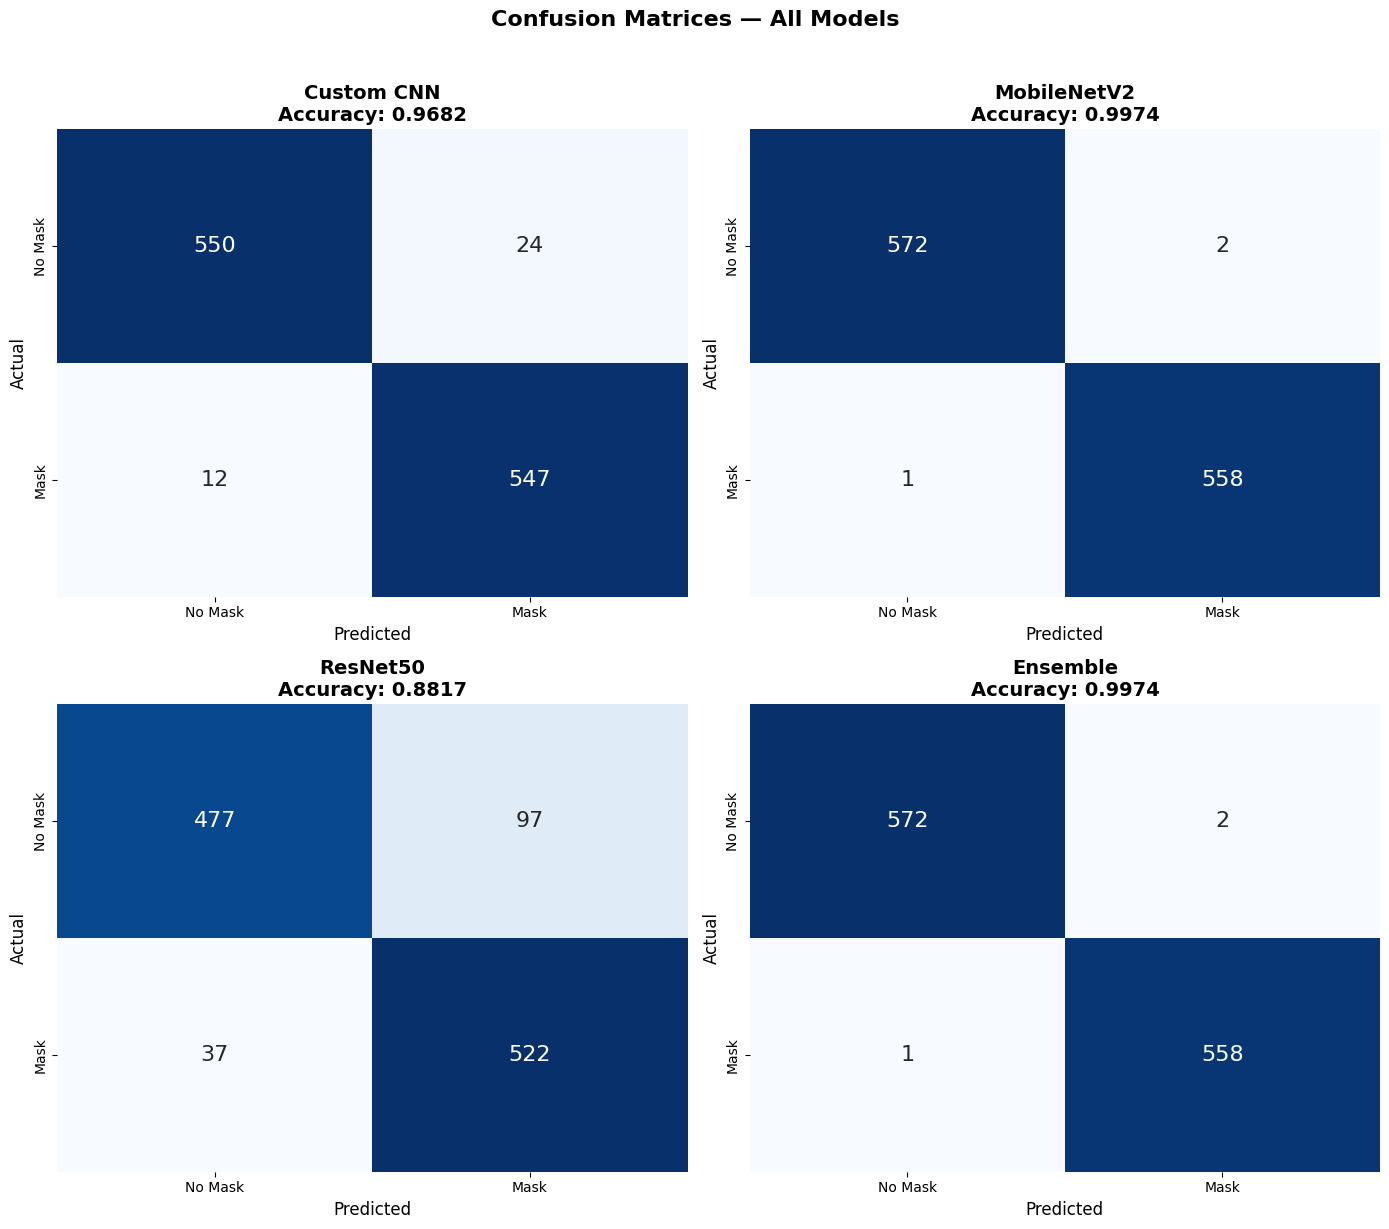

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, name in enumerate(all_model_names):
    probs = test_preds[name]
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=axes[idx], cbar=False,
        annot_kws={'size': 16}
    )
    acc = accuracy_score(y_test, preds)
    axes[idx].set_title(f'{name}\nAccuracy: {acc:.4f}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=12)
    axes[idx].set_ylabel('Actual', fontsize=12)

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.3 ROC Curves with AUC

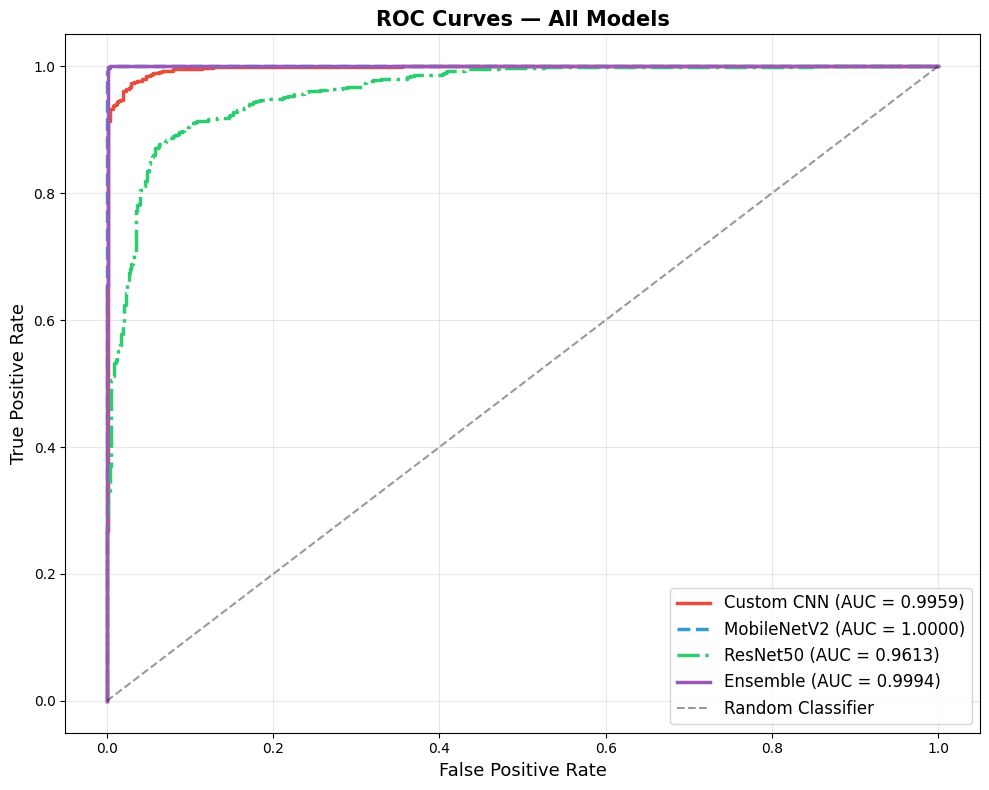

In [12]:
plt.figure(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
line_styles = ['-', '--', '-.', '-']

for idx, name in enumerate(all_model_names):
    probs = test_preds[name]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        color=colors[idx], linestyle=line_styles[idx], linewidth=2.5,
        label=f'{name} (AUC = {roc_auc:.4f})'
    )

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(fontsize=12, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Precision-Recall Curves

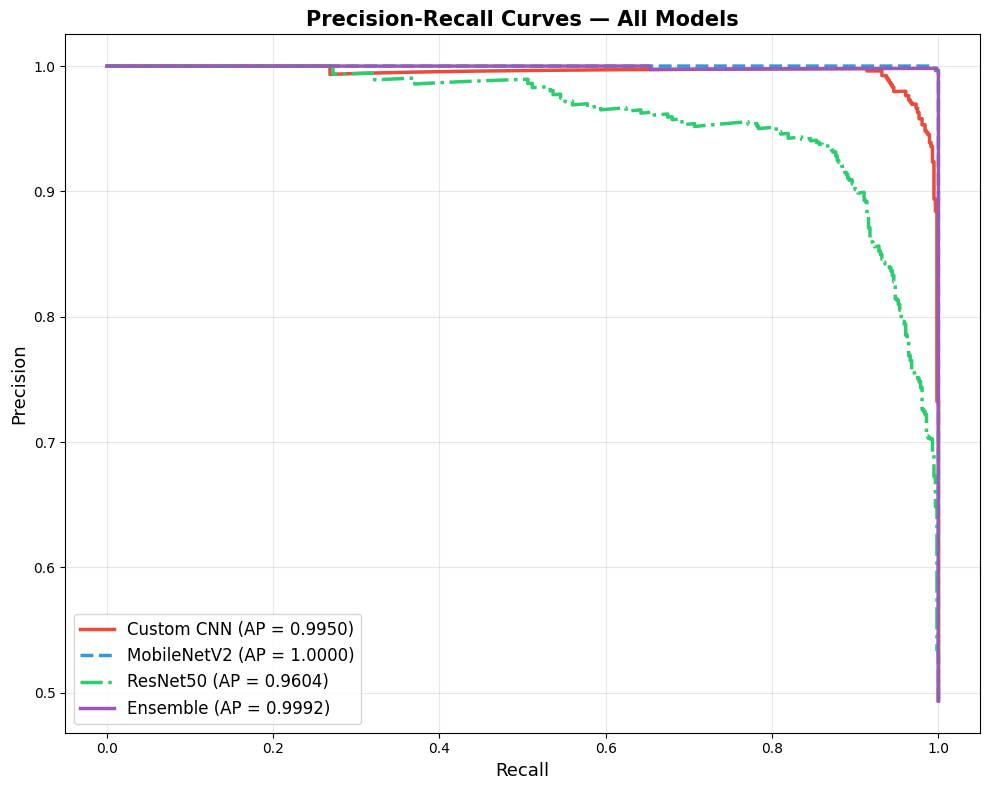

In [13]:
plt.figure(figsize=(10, 8))

for idx, name in enumerate(all_model_names):
    probs = test_preds[name]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(
        recall_vals, precision_vals,
        color=colors[idx], linestyle=line_styles[idx], linewidth=2.5,
        label=f'{name} (AP = {ap:.4f})'
    )

plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(fontsize=12, loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'pr_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Bar Chart — Metric Comparison Across Models

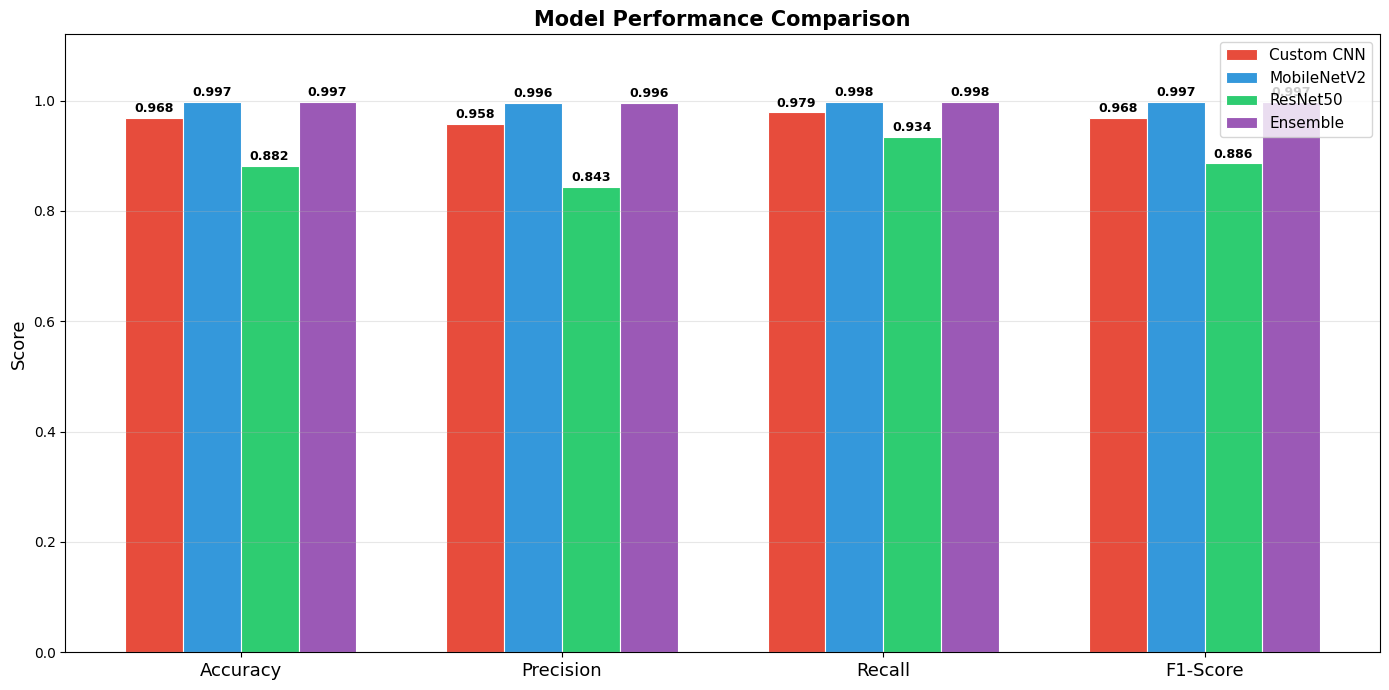

In [14]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x = np.arange(len(metrics_to_plot))
width = 0.18
offsets = np.arange(len(all_model_names)) - (len(all_model_names) - 1) / 2

fig, ax = plt.subplots(figsize=(14, 7))

for i, name in enumerate(all_model_names):
    values = [results_df.loc[name, m] for m in metrics_to_plot]
    bars = ax.bar(
        x + offsets[i] * width, values, width,
        label=name, color=colors[i], edgecolor='white', linewidth=0.8
    )
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'metrics_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Best Model Summary

In [15]:
# Determine the best model by F1-Score (or change to 'Accuracy' if preferred)
best_model_name = results_df['F1-Score'].idxmax()
best_metrics = results_df.loc[best_model_name]

print("=" * 60)
print(f"  BEST MODEL: {best_model_name}")
print("=" * 60)
for metric, value in best_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")
print("=" * 60)

  BEST MODEL: MobileNetV2
  Accuracy    : 0.9974
  Precision   : 0.9964
  Recall      : 0.9982
  F1-Score    : 0.9973


---

## 4. Save Results & Prepare for Deployment

We save all evaluation artefacts and copy the best-performing model(s) into a dedicated `deployment/` folder on Google Drive.

In [16]:
# ── Save evaluation results ────────────────────────────────────────────────
eval_results = {
    'best_model': best_model_name,
    'metrics': results_df.to_dict(orient='index'),
    'ensemble_weights': weights_dict,
}

results_path = os.path.join(MODEL_DIR, 'evaluation_results.json')
with open(results_path, 'w') as f:
    json.dump(eval_results, f, indent=2)
print(f"Evaluation results saved to: {results_path}")

# ── Create deployment folder ──────────────────────────────────────────────
DEPLOY_DIR = os.path.join(DRIVE_BASE, 'deployment')
os.makedirs(DEPLOY_DIR, exist_ok=True)

# Copy ensemble weights
shutil.copy2(weights_path, DEPLOY_DIR)

# Copy all individual models (needed for ensemble inference)
model_files = ['custom_cnn.keras', 'mobilenetv2.keras', 'resnet50.keras']
for mf in model_files:
    src = os.path.join(MODEL_DIR, mf)
    if os.path.exists(src):
        shutil.copy2(src, DEPLOY_DIR)
        print(f"  Copied {mf} -> deployment/")

# Copy evaluation results
shutil.copy2(results_path, DEPLOY_DIR)

print(f"\nDeployment folder ready: {DEPLOY_DIR}")
print("Contents:")
for f in os.listdir(DEPLOY_DIR):
    size_mb = os.path.getsize(os.path.join(DEPLOY_DIR, f)) / (1024 * 1024)
    print(f"  {f:35s} ({size_mb:.1f} MB)")

Evaluation results saved to: /content/drive/MyDrive/Face_Mask_Detection/models/evaluation_results.json
  Copied custom_cnn.keras -> deployment/
  Copied mobilenetv2.keras -> deployment/
  Copied resnet50.keras -> deployment/

Deployment folder ready: /content/drive/MyDrive/Face_Mask_Detection/deployment
Contents:
  ensemble_weights.json               (0.0 MB)
  custom_cnn.keras                    (5.7 MB)
  mobilenetv2.keras                   (24.6 MB)
  resnet50.keras                      (225.0 MB)
  evaluation_results.json             (0.0 MB)


---

## Summary

In this notebook we:

1. **Built a Weighted Average Ensemble** by optimising combination weights on the validation set using `scipy.optimize.minimize` (SLSQP with simplex constraints).
2. **Evaluated all four models** (Custom CNN, MobileNetV2, ResNet50, Ensemble) on the held-out test set.
3. **Visualised performance** through confusion matrices, ROC curves (with AUC), Precision-Recall curves (with AP), and grouped bar charts.
4. **Identified the best model** and prepared a deployment-ready folder on Google Drive.

### Key Takeaways

- The ensemble approach reduces variance and leverages the complementary strengths of architectures with very different inductive biases (custom shallow CNN vs. pretrained deep networks).
- Transfer-learning models (MobileNetV2, ResNet50) generally outperform a from-scratch CNN on limited data, and the ensemble can push performance even further.
- All metrics, weights, and models are saved for reproducibility and downstream deployment.

**Next →** In Notebook 5, we will apply explainability techniques (Grad-CAM, SHAP, LIME) to understand *what* the best model has learned.